In [1]:
import torch

# Patch torch.load to use weights_only=False (safe for OGB's trusted data)
_original_load = torch.load
torch.load = lambda *args, **kwargs: _original_load(*args, **{**kwargs, "weights_only": False})

from ogb.graphproppred import PygGraphPropPredDataset

dataset = PygGraphPropPredDataset(root="/tmp/ogb.molhiv", name="ogbg-molhiv")

# Restore original behavior
torch.load = _original_load

/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ogbg-molhiv has been updated.


Downloaded 0.00 GB: 100%|██████████| 3/3 [00:04<00:00,  1.34s/it]
Processing...


Extracting /tmp/ogb.molhiv/hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 41127/41127 [00:00<00:00, 214527.16it/s]


Converting graphs into PyG objects...


100%|██████████| 41127/41127 [00:00<00:00, 62182.58it/s]


Saving...


Done!


In [2]:
# let's first split the data
split_idx = dataset.get_idx_split()

from torch_geometric.loader import DataLoader
train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
val_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)


In [ ]:
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
import torch.nn as nn
from torch_geometric.nn import global_mean_pool
from ogb.graphproppred.mol_encoder import AtomEncoder

class GCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, p: float):
        super().__init__()

        self.encoder = AtomEncoder(emb_dim=in_channels)
        self.conv_in = GCNConv(in_channels, hidden_channels, add_self_loops=True, normalize=True)
        self.conv_out = GCNConv(hidden_channels, hidden_channels, add_self_loops=True, normalize=True)
        self.dropout = nn.Dropout(p)
        self.relu = nn.ReLU()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(hidden_channels, out_channels),
        )


    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: int=None):
        out = self.encoder(x)
        out = self.conv_in(out, edge_index)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv_out(out, edge_index)
        out = self.relu(out)
        out = self.dropout(out)
        out = global_mean_pool(out, batch)
        return self.mlp(out)

class GATNN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, heads: int, dropout: float, add_self_loops: bool):
        super().__init__()

        self.encoder = AtomEncoder(in_channels)
        self.conv_in = GATConv(in_channels, hidden_channels, heads, dropout=dropout, add_self_loops=add_self_loops)
        self.conv_out = GATConv(hidden_channels, hidden_channels, heads, dropout=dropout, add_self_loops=add_self_loops)
        self.relu = nn.ReLU()
        self.mlp = nn.Linear(hidden_channels, out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: int=None):
        x = self.encoder(x)
        x = self.conv_in(x, edge_index)
        x = self.relu(x)
        x = self.conv_out(x, edge_index)
        x = self.relu(x)
        x = global_mean_pool(x, batch)
        return self.mlp(x)
    
class SageNN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, dropout: float):
        super().__init__()

        self.encoder = AtomEncoder(in_channels)
        self.conv_in = SAGEConv(in_channels, hidden_channels, normalize=False)
        self.conv_hidden1 = SAGEConv(hidden_channels, hidden_channels, normalize=False)
        self.conv_hidden2 = SAGEConv(hidden_channels, hidden_channels, normalize=False)
        self.conv_out = SAGEConv(hidden_channels, hidden_channels, normalize=False)
        self.relu = nn.ReLU()
        self.mlp = self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_channels, out_channels),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: int=None):
        x = self.encoder(x)

        x = self.conv_in(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv_hidden1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv_hidden2(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv_out(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        return self.mlp(x)


# testings
testing_data = dataset[0]
testing_model = GCN(128, 32, 2, 0.5)
testing_out = testing_model(testing_data.x, testing_data.edge_index)

testing_gat_model = GATNN(
    in_channels=128,
    hidden_channels=32,
    out_channels=2,
    heads=1,
    dropout=0.5,
    add_self_loops=False
    )
testing_out = testing_gat_model(testing_data.x, testing_data.edge_index)

In [ ]:
def train(model: GCN, loader: DataLoader, optimizer:torch.optim, criterion: nn.CrossEntropyLoss):
    model.train()
    loss = 0
    total_sample = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        l = criterion(out, batch.y.flatten())
        l.backward()
        optimizer.step()
        loss += (l.item() * batch.y.shape[0])
        total_sample += batch.y.shape[0]
    loss /= total_sample
    return loss

# testings
testing_loader = DataLoader(dataset[:32], batch_size=8)
testing_optimizer = torch.optim.Adam(testing_model.parameters(), lr=0.001)
testing_criterion = nn.CrossEntropyLoss()
testing_loss = train(testing_model, testing_loader, testing_optimizer, testing_criterion)

@torch.no_grad()
def val(model: GCN, loader: DataLoader, criterion: nn.CrossEntropyLoss):
    loss = 0
    total_sample = 0
    model.eval()
    for batch in loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        l = criterion(out, batch.y.flatten())
        loss += (l.item()*batch.y.shape[0])
        total_sample += batch.y.shape[0]
    loss /= total_sample
    return loss

# testings
testing_loss = val(testing_model, testing_loader, testing_criterion)

@torch.no_grad()
def predict(model: GCN, dataloader: DataLoader):
    model.eval()
    outs = []
    ys = []
    for loader in dataloader:
        out = model(loader.x, loader.edge_index, loader.batch)
        outs.append(out)
        ys.append(loader.y.flatten())
    return torch.cat(outs, dim=0), torch.cat(ys)

# testings
testing_out, testing_ys = predict(testing_model, testing_loader)

def acc(out:torch.Tensor, y: torch.Tensor):
    out = torch.argmax(out, dim=1)
    return (out == y).float().mean().item()

# testings
accuracy = acc(testing_out, testing_ys)

def prec(out: torch.Tensor, y: torch.Tensor):
    preds = torch.argmax(out, dim=1)
    pred_pos_mask = preds == 1
    if pred_pos_mask.float().sum() > 0:
        return (preds==y)[pred_pos_mask].float().mean().item()
    else:
        return 0

# testings
precision = prec(testing_out, testing_ys)

def rec(out: torch.Tensor, y: torch.Tensor):
    preds = torch.argmax(out, dim=1)
    pos_classes = y == 1
    return (preds == pos_classes)[pos_classes].float().mean().item()

# testings
recall = rec(testing_out, testing_ys)

# testings
mock_train_loader = DataLoader(dataset[:1000], batch_size=64)
mock_val_loader = DataLoader(dataset[1000:2000], batch_size=64)
mock_model = testing_model = GCN(128, 64, 2, 0.5)
mock_optimizer = torch.optim.Adam(mock_model.parameters(), lr=0.001, weight_decay=0.001)
mock_criterion = nn.CrossEntropyLoss()

from sklearn.metrics import roc_auc_score
def roc_auc(outs: torch.Tensor, ys: torch.Tensor):
    y_score = torch.sigmoid(outs)[:, 1]
    y_score = y_score.numpy()
    ys = ys.numpy()
    return roc_auc_score(ys, y_score)

from dataclasses import dataclass, field
from typing import Callable

@dataclass
class Metric:
    name: str
    fn: Callable
    split: str
    history: list = field(default_factory=list)

    def compute(self, outs: torch.Tensor, ys: torch.Tensor):
        value = self.fn(outs, ys)
        self.history.append(value)
        return value

from tqdm import tqdm
def train_val(model: GCN, epochs: int, train_loader: DataLoader, val_loader: DataLoader, optimizer: torch.optim, criterion: nn.CrossEntropyLoss, metrics: list[Metric]):
    train_loss = []
    val_loss = []
    for _ in tqdm(range(epochs)):
        train_loss.append(train(model, train_loader, optimizer, criterion))
        val_loss.append(val(model, val_loader, criterion))
        preds = {
            "train": predict(model, train_loader),
            "val": predict(model, val_loader)
            }
        
        for m in metrics:
            outs, ys = preds[m.split]
            m.compute(outs, ys)

    result = {"model": model, "train_loss": train_loss, "val_loss": val_loss}
    for m in metrics:
        result[m.name] = m.history
    return result


In [5]:
import numpy as np

def calculate_label_imbalance(y: torch.Tensor):
    _, counts = np.unique(y, return_counts=True)
    class_weights = 1.0/(torch.Tensor(counts))
    class_weights = class_weights/class_weights.sum()
    sample_weights = class_weights[y]
    return class_weights, sample_weights

In [6]:
import matplotlib.pyplot as plt

def plot_results(results):
    _, axs = plt.subplots(2, 3, figsize=(15, 10))

    # Loss
    axs[0, 0].plot(results["train_loss"], label="train_loss")
    axs[0, 0].plot(results["val_loss"], label="val_loss")
    axs[0, 0].set_xlabel("epochs")
    axs[0, 0].set_ylabel("loss")
    axs[0, 0].legend()
    axs[0, 0].set_title("Loss")

    # Precision
    axs[0, 1].plot(results["train_prec"], label="train_prec", color="#2166ac", linestyle="-", linewidth=2)
    axs[0, 1].plot(results["val_prec"], label="val_prec", color="#67a9cf", linestyle="--", linewidth=2)
    axs[0, 1].set_xlabel("epochs")
    axs[0, 1].set_ylabel("precision")
    axs[0, 1].legend()
    axs[0, 1].set_title("Precision")

    # Accuracy
    axs[0, 2].plot(results["train_acc"], label="train_acc", color="#b2182b", linestyle="-", linewidth=2)
    axs[0, 2].plot(results["val_acc"], label="val_acc", color="#ef8a62", linestyle="--", linewidth=2)
    axs[0, 2].set_xlabel("epochs")
    axs[0, 2].set_ylabel("accuracy")
    axs[0, 2].legend()
    axs[0, 2].set_title("Accuracy")

    # Recall
    axs[1, 0].plot(results["train_rec"], label="train_rec", color="#1b7837", linestyle="-", linewidth=2)
    axs[1, 0].plot(results["val_rec"], label="val_rec", color="#7fbf7b", linestyle="--", linewidth=2)
    axs[1, 0].set_xlabel("epochs")
    axs[1, 0].set_ylabel("recall")
    axs[1, 0].legend()
    axs[1, 0].set_title("Recall")

    # ROC AUC
    axs[1, 1].plot(results["train_roc_auc"], label="train_roc_auc", color="#1b7837", linestyle="-", linewidth=2)
    axs[1, 1].plot(results["val_roc_auc"], label="val_roc_auc", color="#7fbf7b", linestyle="--", linewidth=2)
    axs[1, 1].set_xlabel("epochs")
    axs[1, 1].set_ylabel("roc_auc")
    axs[1, 1].legend()
    axs[1, 1].set_title("ROC AUC")

    # Hide the empty subplot
    axs[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
size = 10000

train_dataset = dataset[split_idx["train"]][:size]
val_dataset = dataset[split_idx["valid"]][:size]

sample_labels = [dataset[i].y.squeeze() for i in range(len(train_dataset))]
class_weights, sample_weights = calculate_label_imbalance(sample_labels)

from torch.utils.data import WeightedRandomSampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

mock_train_loader = DataLoader(train_dataset, batch_size=256, sampler=sampler)
mock_val_loader = DataLoader(val_dataset, batch_size=256)

mock_model = GCN(64, 64, 2, 0.5)
# mock_model = SageNN(128, 128, 2, 0.5)
mock_optimizer = torch.optim.Adam(mock_model.parameters(), lr=0.001, weight_decay=0.001)

mock_metrics = [
    Metric("train_prec", fn=prec, split="train"),
    Metric("val_prec", fn=prec, split="val"),

    Metric("train_acc", fn=acc, split="train"),
    Metric("val_acc", fn=acc, split="val"),

    Metric("train_rec", fn=rec, split="train"),
    Metric("val_rec", fn=rec, split="val"),

    Metric("train_roc_auc", fn=roc_auc, split="train"),
    Metric("val_roc_auc", fn=roc_auc, split="val")
]

mock_criterion = nn.CrossEntropyLoss(weight=class_weights)
mock_results = train_val(mock_model, 50, mock_train_loader, mock_val_loader, mock_optimizer, mock_criterion, mock_metrics)

100%|██████████| 50/50 [04:42<00:00,  5.64s/it]


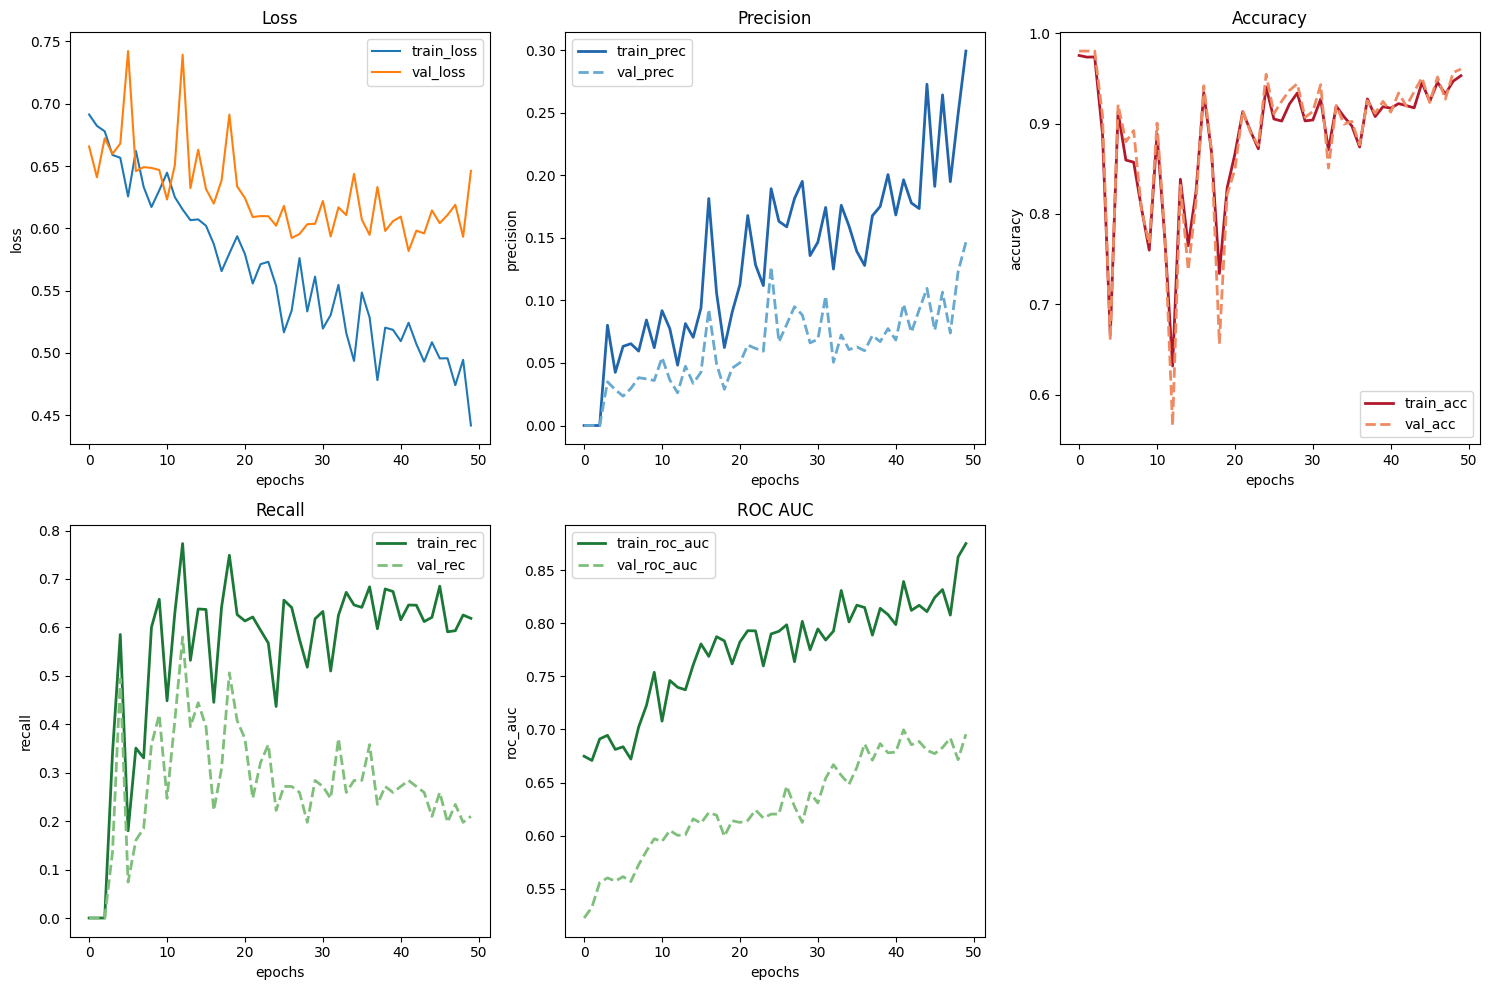

In [35]:
plot_results(mock_results)